In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
import numpy as np

def convert_credit_history_age(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value)
    years = 0
    months = 0
    
    if "Years" in value:
        years = int(value.split(" Years")[0])
    
    if "Months" in value:
        months_part = value.split("and ")[-1].split(" Months")[0]
        months = int(months_part)
    
    return years * 12 + months


def clean_data(df):
    df = df.copy()
    
    placeholders = ["_", "_______", "!@9#%8"]
    df = df.replace(placeholders, np.nan)
    
    numeric_like_cols = [
        "Age",
        "Annual_Income",
        "Num_of_Loan",
        "Num_of_Delayed_Payment",
        "Changed_Credit_Limit",
        "Outstanding_Debt",
        "Amount_invested_monthly",
        "Monthly_Balance",
    ]
    
    for col in numeric_like_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace("_", "", regex=False)
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")
    
    if "Credit_History_Age" in df.columns:
        df["Credit_History_Age_Months"] = df["Credit_History_Age"].apply(
            convert_credit_history_age
        )
        df = df.drop(columns=["Credit_History_Age"])
    
    drop_cols = ["ID", "Name", "SSN"]
    df = df.drop(columns=[col for col in drop_cols if col in df.columns])
    
    if "Age" in df.columns:
        df.loc[~df["Age"].between(18, 100), "Age"] = np.nan
    
    if "Num_Bank_Accounts" in df.columns:
        df.loc[~df["Num_Bank_Accounts"].between(0, 20), "Num_Bank_Accounts"] = np.nan
    
    if "Num_Credit_Card" in df.columns:
        df.loc[~df["Num_Credit_Card"].between(0, 20), "Num_Credit_Card"] = np.nan
    
    if "Interest_Rate" in df.columns:
        df.loc[~df["Interest_Rate"].between(0, 100), "Interest_Rate"] = np.nan
    
    if "Num_of_Loan" in df.columns:
        df.loc[~df["Num_of_Loan"].between(0, 20), "Num_of_Loan"] = np.nan
    
    if "Delay_from_due_date" in df.columns:
        df.loc[df["Delay_from_due_date"] < 0, "Delay_from_due_date"] = np.nan
    
    if "Num_of_Delayed_Payment" in df.columns:
        df.loc[~df["Num_of_Delayed_Payment"].between(0, 100), "Num_of_Delayed_Payment"] = np.nan
    
    if "Num_Credit_Inquiries" in df.columns:
        df.loc[~df["Num_Credit_Inquiries"].between(0, 100), "Num_Credit_Inquiries"] = np.nan
    
    if "Monthly_Balance" in df.columns:
        df.loc[df["Monthly_Balance"] < 0, "Monthly_Balance"] = np.nan
    
    return df

In [4]:
train_df = pd.read_csv("../data/raw/train.csv")

clean_df = clean_data(train_df)

target = "Credit_Score"

X = clean_df.drop(columns=[target])
y = clean_df[target]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_valid.shape)
print(y_train.value_counts(normalize=True))
print(y_valid.value_counts(normalize=True))

/var/folders/gw/6hw2mnqn2p3c3ylx1sjb3gsw0000gn/T/ipykernel_54662/625432821.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("../data/raw/train.csv")


(80000, 24) (20000, 24)
Credit_Score
Standard    0.531737
Poor        0.289988
Good        0.178275
Name: proportion, dtype: float64
Credit_Score
Standard    0.53175
Poor        0.28995
Good        0.17830
Name: proportion, dtype: float64


In [5]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [6]:
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ),
    "DecisionTree": DecisionTreeClassifier(
        max_depth=15,
        class_weight="balanced",
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [7]:
results = []

for model_name, model in models.items():
    print("=" * 70)
    print(model_name)
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_valid)
    
    accuracy = accuracy_score(y_valid, y_pred)
    macro_f1 = f1_score(y_valid, y_pred, average="macro")
    macro_recall = recall_score(y_valid, y_pred, average="macro")
    
    results.append({
        "model": model_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "macro_recall": macro_recall
    })
    
    print("accuracy:", accuracy)
    print("macro_f1:", macro_f1)
    print("macro_recall:", macro_recall)
    print()
    print(classification_report(y_valid, y_pred))

LogisticRegression


/Users/hanhalam/Desktop/DS_team6/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/hanhalam/Desktop/DS_team6/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


accuracy: 0.74545
macro_f1: 0.737876009609101
macro_recall: 0.772242391191897

              precision    recall  f1-score   support

        Good       0.60      0.82      0.69      3566
        Poor       0.73      0.81      0.77      5799
    Standard       0.84      0.68      0.76     10635

    accuracy                           0.75     20000
   macro avg       0.72      0.77      0.74     20000
weighted avg       0.77      0.75      0.75     20000

DecisionTree
accuracy: 0.7001
macro_f1: 0.6927360024136718
macro_recall: 0.7333482236370662

              precision    recall  f1-score   support

        Good       0.54      0.80      0.64      3566
        Poor       0.68      0.78      0.72      5799
    Standard       0.82      0.63      0.71     10635

    accuracy                           0.70     20000
   macro avg       0.68      0.73      0.69     20000
weighted avg       0.73      0.70      0.70     20000

RandomForest
accuracy: 0.62475
macro_f1: 0.6227114634601059
macro_

In [8]:
results_df = pd.DataFrame(results).sort_values(
    by="macro_f1",
    ascending=False
)

results_df

,model,accuracy,macro_f1,macro_recall
0,LogisticRegression,0.74545,0.737876,0.772242
1,DecisionTree,0.70010,0.692736,0.733348
3,GradientBoosting,0.69250,0.663202,0.656480
2,RandomForest,0.62475,0.622711,0.692151


/Users/hanhalam/Desktop/DS_team6/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/hanhalam/Desktop/DS_team6/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


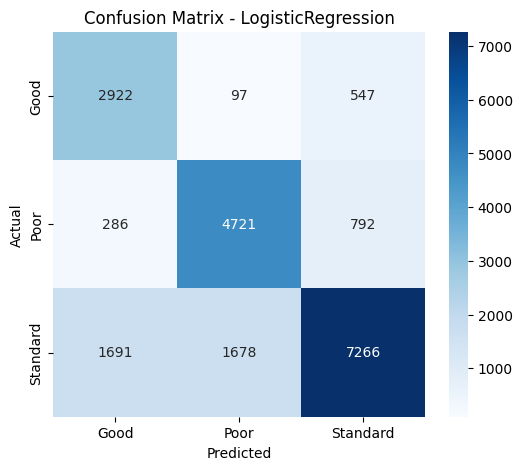

In [9]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipeline.fit(X_train, y_train)
best_pred = best_pipeline.predict(X_valid)

cm = confusion_matrix(y_valid, best_pred, labels=best_pipeline.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_pipeline.classes_,
    yticklabels=best_pipeline.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [10]:
results_df

,model,accuracy,macro_f1,macro_recall
0,LogisticRegression,0.74545,0.737876,0.772242
1,DecisionTree,0.70010,0.692736,0.733348
3,GradientBoosting,0.69250,0.663202,0.656480
2,RandomForest,0.62475,0.622711,0.692151
